In [13]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

connection=sqlite3.connect('../data/checking-logs.sqlite')

In [14]:
query_1 = '''
SELECT uid, strftime('%w', timestamp) as weekday, COUNT(strftime('%w', timestamp)) AS commits
FROM checker
WHERE uid LIKE "user_%"
GROUP BY uid, weekday
'''

df_week = pd.read_sql(sql=query_1, con=connection)
df_week['weekday'] = df_week['weekday'].astype(int) #чтобы потом можно было сделать reindex

df_week=df_week.pivot_table(index='weekday', columns='uid', values='commits', aggfunc='sum', fill_value=0)
df_week = df_week[df_week.sum(axis=0).sort_values(ascending=False).index]

seq = [1,2,3,4,5,6,0]
df_week = df_week.reindex(seq)
df_week.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
df_week

uid,user_4,user_14,user_2,user_25,user_19,user_26,user_20,user_31,user_10,user_3,...,user_17,user_16,user_27,user_15,user_6,user_11,user_7,user_22,user_23,user_0
Mon,35,50,24,14,7,0,23,5,0,46,...,8,10,0,0,1,0,0,2,0,3
Tue,86,87,131,44,9,1,0,0,16,11,...,4,5,0,0,0,0,5,3,0,0
Wed,33,0,32,15,0,34,8,0,37,0,...,1,0,0,0,4,0,3,0,0,0
Thu,108,17,4,40,78,51,96,7,77,7,...,17,14,15,5,2,0,0,2,6,0
Fri,61,0,0,10,10,2,7,35,1,59,...,0,0,0,0,0,0,0,0,0,0
Sat,0,79,31,66,21,16,3,90,4,3,...,32,0,0,4,2,0,0,0,0,0
Sun,45,26,13,44,51,69,28,7,2,8,...,0,31,27,20,9,8,0,1,0,0


In [15]:
query_2 = '''
SELECT uid, strftime('%H', timestamp) as hour, COUNT(strftime('%H', timestamp)) AS commits
FROM checker
WHERE uid LIKE "user_%"
GROUP BY uid, hour
'''

df_hour = pd.read_sql(sql=query_2, con=connection)

df_hour=df_hour.pivot_table(index='hour', columns='uid', values='commits', aggfunc='sum', fill_value=0)
df_hour = df_hour[df_hour.sum(axis=0).sort_values(ascending=False).index]

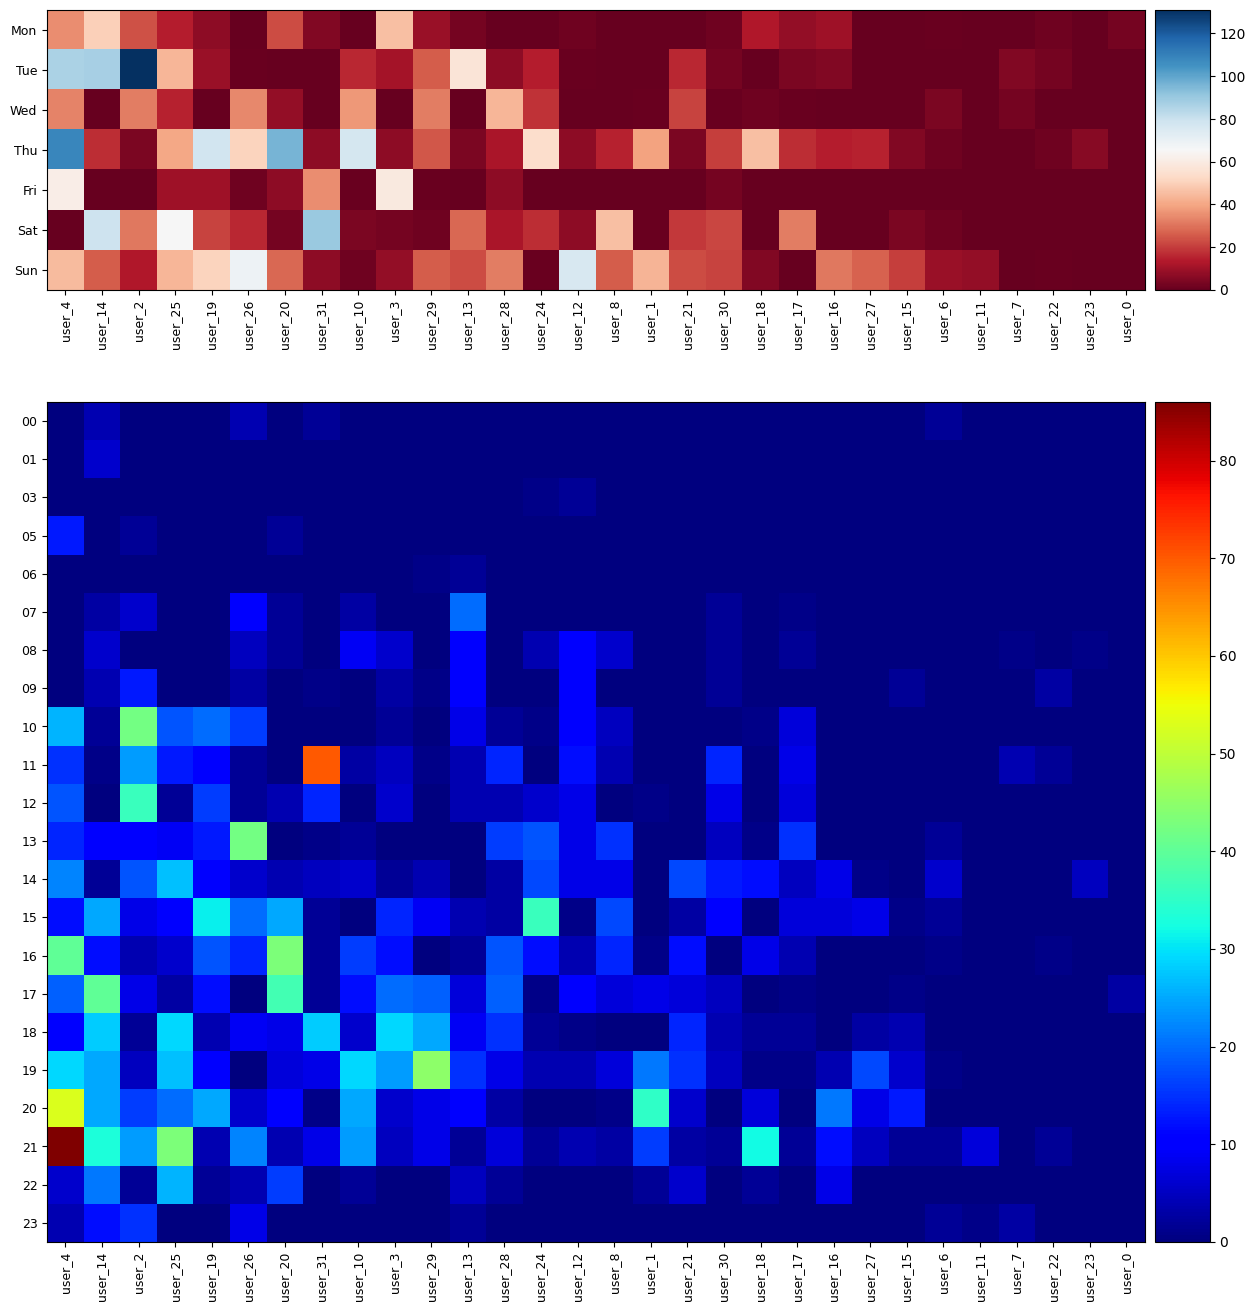

In [16]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 16), gridspec_kw={'height_ratios': [1, 3]})

def heatmap(ax, data, cmap):
    im = ax.imshow(data, cmap=cmap, aspect='auto')
    
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='5%', pad=0.1)
    fig.colorbar(im, cax=cax)
    
    ax.set_xticks(range(len(data.columns)))
    ax.set_xticklabels(data.columns, rotation=90, fontsize=9)
    ax.set_yticks(range(len(data.index)))
    ax.set_yticklabels(data.index, fontsize=9)
    
    return im

heatmap(ax1, df_week, cmap='RdBu')
heatmap(ax2, df_hour, cmap='jet')

plt.show()

In [17]:
connection.close()

«У какого пользователя больше всего коммитов по вторникам?» Ответ: user_*. **user_25**  
«У какого пользователя больше всего коммитов по четвергам?» Ответ: user_*. **user_4**  
«В какой день недели пользователи не любят делать много коммитов?» Ответ, например: Monday. **Friday**  
«Какой пользователь сделал больше всего коммитов и в какое время?» Ответ: user_1, 15. **user_4 в 21**